# Exploratory Data Analysis  - CNEFE Addresses

## Setup

In [ ]:
import os
from pathlib import Path
from pyspark.sql import SparkSession
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="pyspark")

spark = (
    SparkSession.builder.appName("Read Integrated Data")
    .config("spark.driver.memory", "16g")
    .config("spark.executor.memory", "16g")
    .getOrCreate()
)

current_path = os.getcwd()
project_root = Path(current_path).parent.parent
os.chdir(project_root)
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.getcwd()

'/home/lucas-vital/projects/brazilian_address_linkage'

## Read Data

In [18]:
def read_json(path: str | Path):
    with open(path, "r") as f:
        return json.load(f)

In [37]:


CNEFE_VARS_DICT = read_json("config/dicionario_cnefe.json")
df = spark.read.parquet("data/integrated/integrated_cnefe_addresses.parquet")

In [3]:
df.groupBy("COD_UNICO_ENDERECO").count().filter("count > 1").orderBy(
    "count", ascending=False
).show(10, False)

+------------------+-----+
|COD_UNICO_ENDERECO|count|
+------------------+-----+
|16360870          |6    |
|211407776         |5    |
|223042492         |5    |
|35577467          |5    |
|1382344           |4    |
|77000911          |4    |
|10846066          |4    |
|22845179          |4    |
|26445019          |4    |
|30865597          |4    |
+------------------+-----+
only showing top 10 rows


In [4]:
df.sample(fraction=0.000001).toPandas()

/home/lucas-vital/projects/brazilian_address_linkage/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/04 07:11:47 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


,COD_UNICO_ENDERECO,COD_UF,COD_MUNICIPIO,COD_DISTRITO,COD_SUBDISTRITO,COD_SETOR,NUM_QUADRA,NUM_FACE,CEP,DSC_LOCALIDADE,...,LATITUDE,LONGITUDE,NV_GEO_COORD,COD_ESPECIE,DSC_ESTABELECIMENTO,COD_INDICADOR_ESTAB_ENDERECO,COD_INDICADOR_CONST_ENDERECO,COD_INDICADOR_FINALIDADE_CONST,COD_TIPO_ESPECI,UF
0,90795904,29,2927408,292740805,29274080507,292740805070348P,3,3,40255370,MATATU,...,-12.974668,-38.494331,1,1,NaN,NaN,NaN,NaN,101.0,BA
1,211389698,35,3550308,355030870,35503087000,355030870000155P,1,4,02462081,IMIRIM,...,-23.488943,-46.643614,1,1,NaN,NaN,NaN,NaN,101.0,SP
2,30329380,31,3106200,310620005,31062000564,310620005640244P,7,2,31140540,SILVEIRA,...,-19.891818,-43.929845,1,1,NaN,NaN,NaN,NaN,103.0,MG
3,31591933,31,3106200,310620005,31062000568,310620005680222P,2,3,31360150,SANTA TEREZINHA,...,-19.868561,-44.009899,1,6,CIRO CONTABILIDADE,1,NaN,NaN,NaN,MG
4,191280447,29,2918001,291800105,29180010500,291800105000291P,8,3,45210130,MANDACARU,...,-13.869847,-40.087576,1,1,NaN,NaN,NaN,NaN,101.0,BA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,1404765,11,1100155,110015505,11001550500,110015505000039P,1,2,76920000,ALVORADA,...,-10.718612,-62.246147,1,1,NaN,NaN,NaN,NaN,101.0,RO
112,103688035,17,1703008,170300805,17030080500,170300805000016P,6,1,77870000,BAIRRO DE AREIA,...,-7.193062,-47.777077,1,1,NaN,NaN,NaN,NaN,101.0,TO
113,182431869,17,1706001,170600105,17060010500,170600105000017P,0,130,77750000,BELENZINHO,...,-8.624685,-49.144019,1,1,NaN,NaN,NaN,NaN,101.0,TO
114,95896539,41,4103404,410340405,41034040500,410340405000006P,22,1,86640000,CENTRO,...,-22.790492,-51.710885,1,1,NaN,NaN,NaN,NaN,101.0,PR


## analyse missingness

In [5]:
from pyspark.sql import functions as F

total_rows = df.count()

fulfillment_exprs = [
    F.struct(
        F.lit(c).alias("column"),
        (F.count(F.col(c)) / F.lit(total_rows) * 100).alias("fulfillment_pct"),
    )
    for c in df.columns
]

result = (
    df.select(F.array(*fulfillment_exprs).alias("stats"))
    .selectExpr("explode(stats) as stats")
    .select("stats.column", "stats.fulfillment_pct")
)

result.orderBy(F.col("fulfillment_pct").desc()).show(
    df.columns.__len__(), truncate=False
)

+------------------------------+--------------------+
|column                        |fulfillment_pct     |
+------------------------------+--------------------+
|COD_UNICO_ENDERECO            |100.0               |
|COD_UF                        |100.0               |
|COD_MUNICIPIO                 |100.0               |
|COD_DISTRITO                  |100.0               |
|COD_SUBDISTRITO               |100.0               |
|COD_SETOR                     |100.0               |
|NUM_QUADRA                    |100.0               |
|NUM_FACE                      |100.0               |
|CEP                           |100.0               |
|NOM_TIPO_SEGLOGR              |100.0               |
|NOM_SEGLOGR                   |100.0               |
|NUM_ENDERECO                  |100.0               |
|LATITUDE                      |100.0               |
|LONGITUDE                     |100.0               |
|NV_GEO_COORD                  |100.0               |
|COD_ESPECIE                

## análise Contagem valores dos campos

In [6]:
for c in df.columns:
    print(f"Column: {c}")
    df.filter(F.col(c).isNotNull()).groupBy(c).count().orderBy(
        F.col("count").desc()
    ).show(100, truncate=False)

Column: COD_UNICO_ENDERECO


+------------------+-----+
|COD_UNICO_ENDERECO|count|
+------------------+-----+
|16360870          |6    |
|35577467          |5    |
|211407776         |5    |
|223042492         |5    |
|431787            |4    |
|6034064           |4    |
|28138586          |4    |
|32354636          |4    |
|39214224          |4    |
|57507653          |4    |
|59051025          |4    |
|73516017          |4    |
|112749007         |4    |
|193840649         |4    |
|194154002         |4    |
|194767768         |4    |
|205386884         |4    |
|206736177         |4    |
|14578679          |4    |
|29618481          |4    |
|38039397          |4    |
|47152822          |4    |
|49455701          |4    |
|52543956          |4    |
|77000278          |4    |
|93645838          |4    |
|97967158          |4    |
|98174303          |4    |
|110800014         |4    |
|192351829         |4    |
|193230119         |4    |
|1382344           |4    |
|10846066          |4    |
|22845179          |4    |
|

+------+--------+
|COD_UF|count   |
+------+--------+
|35    |22953725|
|31    |12038190|
|29    |9047296 |
|33    |8962200 |
|43    |6456747 |
|41    |6122025 |
|26    |5120482 |
|23    |4750642 |
|42    |4181139 |
|52    |3960937 |
|15    |3911170 |
|21    |3257843 |
|25    |2228886 |
|32    |2221348 |
|51    |1985314 |
|22    |1891421 |
|24    |1845003 |
|13    |1658970 |
|27    |1626565 |
|50    |1507819 |
|53    |1318887 |
|28    |1258755 |
|11    |965370  |
|17    |848437  |
|12    |410524  |
|16    |312665  |
|14    |260515  |
+------+--------+

Column: COD_MUNICIPIO
+-------------+-------+
|COD_MUNICIPIO|count  |
+-------------+-------+
|3550308      |5689391|
|3304557      |3276028|
|2927408      |1390897|
|5300108      |1318887|
|2304400      |1193529|
|3106200      |1180102|
|4106902      |900459 |
|1302603      |878488 |
|5208707      |777018 |
|4314902      |762239 |
|2611606      |737511 |
|1501402      |618075 |
|3518800      |596864 |
|3509502      |574086 |
|2111300   

+---------------+------+
|COD_SUBDISTRITO|count |
+---------------+------+
|43149020500    |762239|
|35095020500    |515772|
|21113000500    |481179|
|25075070500    |426733|
|35188000500    |387294|
|31702060500    |377919|
|35434020500    |360289|
|35487080500    |359628|
|35522050500    |355399|
|33045570521    |333230|
|35344010500    |328129|
|35478090500    |318929|
|28003080500    |307745|
|33045570523    |305095|
|35499040500    |278596|
|42091020500    |269751|
|33033020500    |254466|
|35498050500    |237406|
|35485000500    |231082|
|13026030512    |227665|
|29274080522    |224957|
|15008000500    |220206|
|33045570524    |219994|
|33045570529    |217627|
|35188001000    |209570|
|31433020500    |209199|
|29274080518    |208721|
|35259040500    |207882|
|35410000500    |206098|
|52011080500    |203530|
|25040090500    |202469|
|26041060500    |201903|
|35060030500    |199387|
|35294010500    |195094|
|33045570517    |192472|
|33045570522    |191472|
|26116060523    |188308|


+----------------+-----+
|COD_SETOR       |count|
+----------------+-----+
|530010805380078P|6495 |
|430463005000020P|2787 |
|530010805060458P|2734 |
|330190005000198P|2658 |
|351500405000339P|2338 |
|430310305000245P|2296 |
|290570110000058P|2269 |
|292530310000024P|2225 |
|430460605000588P|2193 |
|291080015000025P|2125 |
|290070205000158P|2074 |
|291955305000137P|2070 |
|351907105000343P|1991 |
|430460605000076P|1950 |
|420820305000141P|1944 |
|230440005180085P|1888 |
|292530305000164P|1854 |
|410040005000076P|1848 |
|292550105000049P|1839 |
|291840705000282P|1839 |
|110030405000040P|1818 |
|355220505001011P|1813 |
|261160605180086P|1789 |
|330455705360202P|1785 |
|410960905000021P|1739 |
|330455705390097P|1732 |
|291080005110228P|1710 |
|430770805100036P|1694 |
|530010805150174P|1693 |
|510700810000016P|1691 |
|351907105000128P|1688 |
|230440005160271P|1682 |
|430463005000069P|1664 |
|230428505000035P|1649 |
|522185805000333P|1643 |
|270430205070106P|1642 |
|430463005000034P|1634 |


...

+--------------+-------+
|VAL_COMP_ELEM1|count  |
+--------------+-------+
|1             |4633007|
|2             |3603811|
|3             |1754053|
|A             |1111561|
|4             |1040218|
|B             |936825 |
|5             |674059 |
|6             |512843 |
|7             |404015 |
|C             |357059 |
|101           |354299 |
|8             |347489 |
|201           |315200 |
|11            |302663 |
|10            |285449 |
|9             |284860 |
|102           |284718 |
|12            |279819 |
|FUNDOS        |274026 |
|202           |262545 |
|13            |231383 |
|301           |225528 |
|14            |211580 |
|302           |195052 |
|D             |194204 |
|15            |175203 |
|21            |160979 |
|FRENTE        |160334 |
|16            |159227 |
|22            |152874 |
|103           |150571 |
|01            |143488 |
|17            |139758 |
|203           |138790 |
|18            |131722 |
|23            |127322 |
|E             |127234 |


+----------+-----+
|LATITUDE  |count|
+----------+-----+
|-20.703377|1004 |
|-25.347031|877  |
|-23.523219|874  |
|-23.550103|796  |
|-17.739901|774  |
|-22.593764|746  |
|-17.734873|706  |
|-23.486777|677  |
|-23.554553|661  |
|-23.525337|637  |
|-12.939607|623  |
|-23.541159|618  |
|-22.912943|616  |
|-15.609266|611  |
|-23.499574|609  |
|-15.816648|608  |
|-12.299453|606  |
|-12.989096|605  |
|-23.584077|596  |
|-3.741296 |590  |
|-15.631013|587  |
|-3.775399 |586  |
|-23.552242|578  |
|-23.676831|578  |
|-23.53357 |576  |
|-23.004742|574  |
|-25.435868|574  |
|-12.850908|572  |
|-22.990128|571  |
|-30.103382|570  |
|-30.047392|570  |
|-29.909384|569  |
|-23.486815|561  |
|-23.4947  |558  |
|-8.10921  |552  |
|-23.350983|552  |
|-21.685831|550  |
|-3.796107 |548  |
|-22.969163|543  |
|-16.73603 |540  |
|-23.403507|538  |
|-23.147221|536  |
|-22.986807|531  |
|-16.690506|529  |
|-29.974273|525  |
|-25.507241|524  |
|-22.830044|524  |
|-1.368142 |524  |
|-22.898586|523  |
|-23.558598|

+----------+-----+
|LONGITUDE |count|
+----------+-----+
|-48.919712|1011 |
|-49.285104|884  |
|-46.771631|842  |
|-48.630703|778  |
|-43.299967|763  |
|-48.636012|718  |
|-38.493439|668  |
|-46.869385|658  |
|-46.577765|644  |
|-48.449551|633  |
|-46.780648|629  |
|-38.411958|615  |
|-38.477901|613  |
|-48.014896|612  |
|-56.092535|611  |
|-49.262218|605  |
|-38.938995|596  |
|-51.166153|585  |
|-56.070087|584  |
|-51.149382|582  |
|-51.140757|582  |
|-46.71801 |582  |
|-46.711459|580  |
|-43.341258|579  |
|-38.27261 |572  |
|-47.420249|568  |
|-46.614423|567  |
|-38.534125|566  |
|-51.190671|560  |
|-34.907105|560  |
|-43.253808|556  |
|-43.348514|555  |
|-46.433876|550  |
|-49.28577 |549  |
|-48.96653 |547  |
|-48.430815|541  |
|-38.561402|539  |
|-49.161181|538  |
|-46.869371|537  |
|-43.309944|535  |
|-46.449917|527  |
|-48.448495|525  |
|-34.862486|524  |
|-48.448557|524  |
|-49.347413|522  |
|-46.691822|520  |
|-46.536819|518  |
|-48.660753|518  |
|-34.945771|512  |
|-46.816919|

+-------------------------------+------+
|DSC_ESTABELECIMENTO            |count |
+-------------------------------+------+
|VAGO                           |306558|
|BAR                            |285895|
|DEPOSITO                       |239801|
|GARAGEM                        |232729|
|SEM NOME                       |120131|
|GALPAO                         |107896|
|SEM DENOMINACAO                |105884|
|IGREJA                         |82349 |
|SALAO DE BELEZA                |80926 |
|SITIO                          |74906 |
|CRIACAO DE GADO                |72132 |
|OFICINA                        |71979 |
|CURRAL                         |70727 |
|LOJA VAGA                      |70269 |
|MERCEARIA                      |69576 |
|LOJA                           |57994 |
|OFICINA MECANICA               |57012 |
|CASA DE FARINHA                |51357 |
|FAZENDA                        |49116 |
|BARBEARIA                      |46520 |
|LANCHONETE                     |44972 |
|BARRACAO       

+---+--------+
|UF |count   |
+---+--------+
|SP |22953725|
|MG |12038190|
|BA |9047296 |
|RJ |8962200 |
|RS |6456747 |
|PR |6122025 |
|PE |5120482 |
|CE |4750642 |
|SC |4181139 |
|GO |3960937 |
|PA |3911170 |
|MA |3257843 |
|PB |2228886 |
|ES |2221348 |
|MT |1985314 |
|PI |1891421 |
|RN |1845003 |
|AM |1658970 |
|AL |1626565 |
|MS |1507819 |
|DF |1318887 |
|SE |1258755 |
|RO |965370  |
|TO |848437  |
|AC |410524  |
|AP |312665  |
|RR |260515  |
+---+--------+



## Look if null values are consistent

### Based on empty strings

In [7]:
from pyspark.sql import functions as F

categorical_cols = [
    f.name for f in df.schema.fields if str(f.dataType) == "StringType()"
]

empty_string_exprs = [
    F.count(F.when(F.col(c) == "", c)).alias(c) for c in categorical_cols
]

df.select(empty_string_exprs).show(vertical=True, truncate=False)

-RECORD 0-----------------------------
 COD_SETOR                      | 0   
 CEP                            | 0   
 DSC_LOCALIDADE                 | 0   
 NOM_TIPO_SEGLOGR               | 0   
 NOM_TITULO_SEGLOGR             | 0   
 NOM_SEGLOGR                    | 0   
 DSC_MODIFICADOR                | 0   
 NOM_COMP_ELEM1                 | 0   
 VAL_COMP_ELEM1                 | 0   
 NOM_COMP_ELEM2                 | 0   
 VAL_COMP_ELEM2                 | 0   
 NOM_COMP_ELEM3                 | 0   
 VAL_COMP_ELEM3                 | 0   
 NOM_COMP_ELEM4                 | 0   
 VAL_COMP_ELEM4                 | 0   
 NOM_COMP_ELEM5                 | 0   
 VAL_COMP_ELEM5                 | 0   
 DSC_ESTABELECIMENTO            | 0   
 COD_INDICADOR_ESTAB_ENDERECO   | 0   
 COD_INDICADOR_CONST_ENDERECO   | 0   
 COD_INDICADOR_FINALIDADE_CONST | 0   
 UF                             | 0   



### Based on String which sings value is undefined

In [ ]:
import json
from pyspark.sql import functions as F


def get_undefined_expressions_map(col_name: str):
    try:
        with open("config/inconsistent_annotations.json", "r") as f:
            undefined_expressions_map = json.load(f)
            print(f"Loaded undefined expressions for column: {col_name}")
    except FileNotFoundError:
        print("Warning: inconsistent_annotations.json file not found.")
        undefined_expressions_map = {}
    return undefined_expressions_map.get(col_name, [])


def is_undefined(col: F.Column, col_name: str) -> F.Column:
    undefined_expressions = get_undefined_expressions_map(col_name)
    if not undefined_expressions:
        return F.lit(False)
    return col.cast("string").isin(*undefined_expressions)

In [ ]:
import pandas as pd

categorical_cols = [
    f.name for f in df.schema.fields if str(f.dataType) == "StringType()"
]
undefined_count = []
for col_name in categorical_cols:
    print(f"Column: {col_name}")
    count_undefined_df = (
        df.filter(is_undefined(F.col(col_name), col_name))
        .groupBy(F.col(col_name))
        .count()
        .alias("count")
        .orderBy(F.col("count").desc())
    )

    if count_undefined_df.count() > 0:
        total_undefined_count = count_undefined_df.agg(F.sum("count")).collect()[0][0]
        percentage = round((total_undefined_count / total_rows) * 100, 3)
        undefined_count.append(
            {"column": col_name, "count": total_undefined_count, "pct_db": percentage}
        )

pd.DataFrame(undefined_count)

Column: COD_SETOR
Loaded undefined expressions for column: COD_SETOR
Column: CEP
Loaded undefined expressions for column: CEP
Column: DSC_LOCALIDADE
Loaded undefined expressions for column: DSC_LOCALIDADE
Column: NOM_TIPO_SEGLOGR
Loaded undefined expressions for column: NOM_TIPO_SEGLOGR


Column: NOM_TITULO_SEGLOGR
Loaded undefined expressions for column: NOM_TITULO_SEGLOGR
Column: NOM_SEGLOGR
Loaded undefined expressions for column: NOM_SEGLOGR


Column: DSC_MODIFICADOR
Loaded undefined expressions for column: DSC_MODIFICADOR
Column: NOM_COMP_ELEM1
Loaded undefined expressions for column: NOM_COMP_ELEM1
Column: VAL_COMP_ELEM1
Loaded undefined expressions for column: VAL_COMP_ELEM1
Column: NOM_COMP_ELEM2
Loaded undefined expressions for column: NOM_COMP_ELEM2
Column: VAL_COMP_ELEM2
Loaded undefined expressions for column: VAL_COMP_ELEM2
Column: NOM_COMP_ELEM3
Loaded undefined expressions for column: NOM_COMP_ELEM3
Column: VAL_COMP_ELEM3
Loaded undefined expressions for column: VAL_COMP_ELEM3
Column: NOM_COMP_ELEM4
Loaded undefined expressions for column: NOM_COMP_ELEM4
Column: VAL_COMP_ELEM4
Loaded undefined expressions for column: VAL_COMP_ELEM4
Column: NOM_COMP_ELEM5
Loaded undefined expressions for column: NOM_COMP_ELEM5
Column: VAL_COMP_ELEM5
Loaded undefined expressions for column: VAL_COMP_ELEM5
Column: DSC_ESTABELECIMENTO
Loaded undefined expressions for column: DSC_ESTABELECIMENTO
Column: COD_INDICADOR_ESTAB_ENDERECO
Loa

,column,count,pct_db
0,DSC_LOCALIDADE,7089,0.006
1,NOM_TIPO_SEGLOGR,28041,0.025
2,NOM_SEGLOGR,1236474,1.113


In [ ]:
total_rows = df.count()


# Build both conditions (sem filtro / com filtro) in a single pass
exprs = []
for c in df.columns:
    # Sem filtro: apenas remove nulos
    not_null_cond = F.col(c).isNotNull()

    # Com filtro: remove nulos + expressões indefinidas (apenas colunas string)
    if c in categorical_cols:
        full_cond = F.col(c).isNotNull() & (~is_undefined(F.col(c), c))
    else:
        full_cond = not_null_cond

    exprs.append(
        F.struct(
            F.lit(c).alias("column"),
            (F.count(F.when(not_null_cond, F.lit(1))) / F.lit(total_rows) * 100).alias(
                "pct_filtro_null_basico"
            ),
            (F.count(F.when(full_cond, F.lit(1))) / F.lit(total_rows) * 100).alias(
                "pct_com_filtro_null_strito"
            ),
        )
    )

result = (
    df.select(F.array(*exprs).alias("stats"))
    .selectExpr("explode(stats) as stats")
    .select(
        "stats.column",
        "stats.pct_filtro_null_basico",
        "stats.pct_com_filtro_null_strito",
    )
    .withColumn(
        "diferenca",
        F.round(
            F.col("pct_com_filtro_null_strito") - F.col("pct_filtro_null_basico"), 4
        ),
    )
    .withColumn("pct_filtro_null_basico", F.round(F.col("pct_filtro_null_basico"), 4))
    .withColumn(
        "pct_com_filtro_null_strito", F.round(F.col("pct_com_filtro_null_strito"), 4)
    )
)

result.orderBy(F.col("pct_com_filtro_null_strito").desc()).show(
    df.columns.__len__(), truncate=False
)

Loaded undefined expressions for column: COD_SETOR
Loaded undefined expressions for column: CEP
Loaded undefined expressions for column: DSC_LOCALIDADE
Loaded undefined expressions for column: NOM_TIPO_SEGLOGR
Loaded undefined expressions for column: NOM_TITULO_SEGLOGR
Loaded undefined expressions for column: NOM_SEGLOGR
Loaded undefined expressions for column: DSC_MODIFICADOR
Loaded undefined expressions for column: NOM_COMP_ELEM1
Loaded undefined expressions for column: VAL_COMP_ELEM1
Loaded undefined expressions for column: NOM_COMP_ELEM2
Loaded undefined expressions for column: VAL_COMP_ELEM2
Loaded undefined expressions for column: NOM_COMP_ELEM3
Loaded undefined expressions for column: VAL_COMP_ELEM3
Loaded undefined expressions for column: NOM_COMP_ELEM4
Loaded undefined expressions for column: VAL_COMP_ELEM4
Loaded undefined expressions for column: NOM_COMP_ELEM5
Loaded undefined expressions for column: VAL_COMP_ELEM5
Loaded undefined expressions for column: DSC_ESTABELECIMENTO

+------------------------------+----------------------+--------------------------+---------+
|column                        |pct_filtro_null_basico|pct_com_filtro_null_strito|diferenca|
+------------------------------+----------------------+--------------------------+---------+
|COD_UNICO_ENDERECO            |100.0                 |100.0                     |0.0      |
|COD_UF                        |100.0                 |100.0                     |0.0      |
|COD_MUNICIPIO                 |100.0                 |100.0                     |0.0      |
|COD_DISTRITO                  |100.0                 |100.0                     |0.0      |
|COD_SUBDISTRITO               |100.0                 |100.0                     |0.0      |
|COD_SETOR                     |100.0                 |100.0                     |0.0      |
|NUM_QUADRA                    |100.0                 |100.0                     |0.0      |
|NUM_FACE                      |100.0                 |100.0          

#### Plot differences

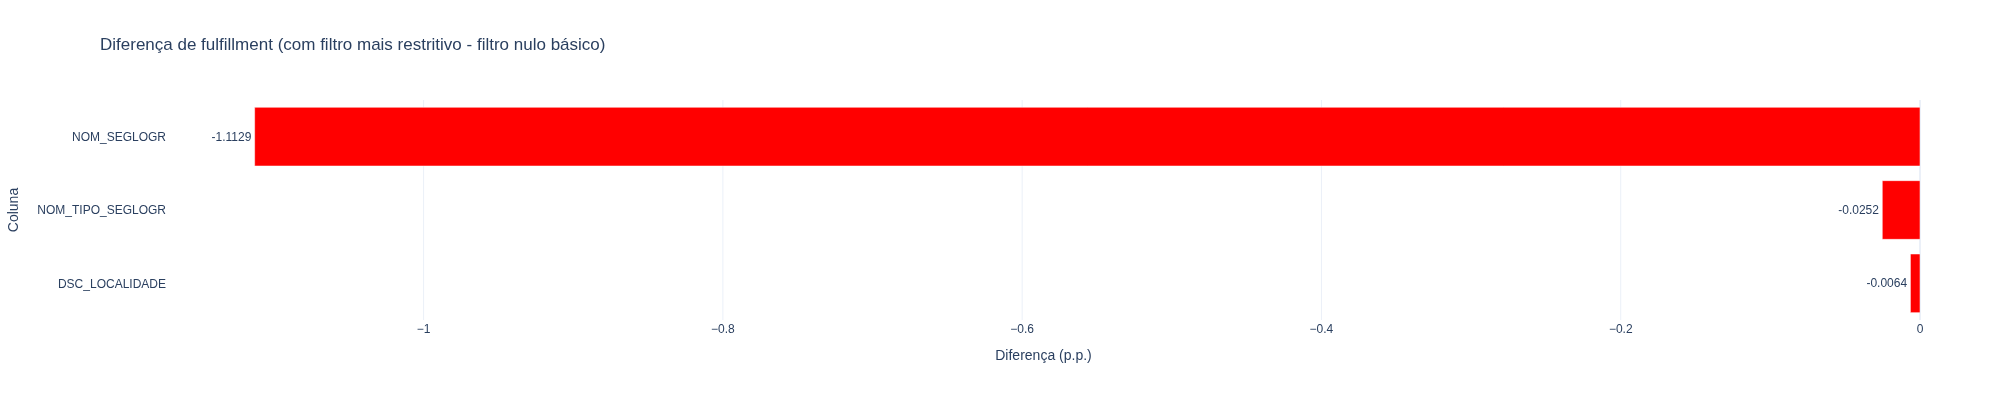

In [11]:
from pyspark.sql import functions as F
import plotly.graph_objects as go
import plotly.io as pio


pio.renderers.default = "png"

diff_df = result.filter(F.col("diferenca") != 0.0).orderBy(F.col("diferenca").asc())

diff_rows = diff_df.select("column", "diferenca").collect()

labels = [row["column"] for row in diff_rows]
data = [round(row["diferenca"], 4) for row in diff_rows]

fig = go.Figure(
    go.Bar(
        x=data,
        y=labels,
        orientation="h",
        marker=dict(color="red"),
        text=[f"{v:.4f}" for v in data],
        textposition="outside",
        hovertemplate="%{y}: %{x:.4f} p.p.<extra></extra>",
    )
)

fig.update_layout(
    title="Diferença de fulfillment (com filtro mais restritivo - filtro nulo básico)",
    xaxis_title="Diferença (p.p.)",
    yaxis_title="Coluna",
    yaxis=dict(autorange="reversed"),  # mantém a maior diferença no topo
    template="plotly_white",
    height=max(400, len(labels) * 40 + 100),
    width=2000,
)


### Caracterização casos onde tem indefinidos

In [13]:
df.filter(
    is_undefined(F.col("NOM_SEGLOGR"), "NOME_LOGRADOURO")
    | is_undefined(F.col("NOM_TIPO_SEGLOGR"), "NOM_TIPO_SEGLOGR")
    | is_undefined(F.col("DSC_LOCALIDADE"), "DSC_LOCALIDADE")
).count()

Loaded undefined expressions for column: NOME_LOGRADOURO
Loaded undefined expressions for column: NOM_TIPO_SEGLOGR
Loaded undefined expressions for column: DSC_LOCALIDADE


35130

#### Por espécie domicílio

In [40]:

mapping = CNEFE_VARS_DICT["COD_ESPECIE"]["valores"]
var_analyzed = "COD_ESPECIE"
(
    df
    .groupBy(var_analyzed)
    .count()
    .withColumn(
        var_analyzed,
        F.col(var_analyzed).cast("string")
    )
    .replace(
        mapping,
        subset=[var_analyzed]
    )
    .orderBy(F.col("count").desc())
    .show(500, truncate=False)
)

+-------------------------------------+--------+
|COD_ESPECIE                          |count   |
+-------------------------------------+--------+
|Domicílio particular                 |90600065|
|Estabelecimento de outras finalidades|11706713|
|Estabelecimento agropecuário         |4058385 |
|Edificação em construção ou reforma  |3541442 |
|Estabelecimento religioso            |579798  |
|Estabelecimento de ensino            |264445  |
|Estabelecimento de saúde             |247510  |
|Domicílio coletivo                   |104517  |
+-------------------------------------+--------+



In [31]:

mapping = CNEFE_VARS_DICT["COD_ESPECIE"]["valores"]
var_analyzed = "COD_ESPECIE"
(
    df
    .filter(
        is_undefined(F.col("NOM_SEGLOGR"), "NOME_LOGRADOURO")
        | is_undefined(F.col("NOM_TIPO_SEGLOGR"), "NOM_TIPO_SEGLOGR")
        | is_undefined(F.col("DSC_LOCALIDADE"), "DSC_LOCALIDADE")
    )
    .groupBy(var_analyzed)
    .count()
    .withColumn(
        var_analyzed,
        F.col(var_analyzed).cast("string")
    )
    .replace(
        mapping,
        subset=[var_analyzed]
    )
    .orderBy(F.col("count").desc())
    .show(500, truncate=False)
)

Loaded undefined expressions for column: NOME_LOGRADOURO
Loaded undefined expressions for column: NOM_TIPO_SEGLOGR
Loaded undefined expressions for column: DSC_LOCALIDADE


+-------------------------------------+-----+
|COD_ESPECIE                          |count|
+-------------------------------------+-----+
|Domicílio particular                 |25887|
|Estabelecimento agropecuário         |3648 |
|Estabelecimento de outras finalidades|3058 |
|Edificação em construção ou reforma  |2214 |
|Estabelecimento religioso            |188  |
|Estabelecimento de ensino            |67   |
|Estabelecimento de saúde             |35   |
|Domicílio coletivo                   |33   |
+-------------------------------------+-----+



#### Por Descricao Localidade

In [39]:
var_analyzed = "COD_TIPO_ESPECI"
mapping = CNEFE_VARS_DICT[var_analyzed]["valores"]

(
    df
    .groupBy(var_analyzed)
    .count()
    .withColumn(
        var_analyzed,
        F.col(var_analyzed).cast("string")
    )
    .replace(
        mapping,
        subset=[var_analyzed]
    )
    .orderBy(F.col("count").desc())
    .show(500, truncate=False)
)

+-----------------------------+--------+
|COD_TIPO_ESPECI              |count   |
+-----------------------------+--------+
|Casa                         |73817837|
|NULL                         |20398293|
|Apartamento                  |13942183|
|Casa de vila ou em condomínio|2442534 |
|Outros                       |502028  |
+-----------------------------+--------+



In [38]:
var_analyzed = "COD_TIPO_ESPECI"
mapping = CNEFE_VARS_DICT[var_analyzed]["valores"]

(
    df
    .filter(
        is_undefined(F.col("NOM_SEGLOGR"), "NOME_LOGRADOURO")
        | is_undefined(F.col("NOM_TIPO_SEGLOGR"), "NOM_TIPO_SEGLOGR")
        | is_undefined(F.col("DSC_LOCALIDADE"), "DSC_LOCALIDADE")
    )
    .groupBy(var_analyzed)
    .count()
    .withColumn(
        var_analyzed,
        F.col(var_analyzed).cast("string")
    )
    .replace(
        mapping,
        subset=[var_analyzed]
    )
    .orderBy(F.col("count").desc())
    .show(500, truncate=False)
)

Loaded undefined expressions for column: NOME_LOGRADOURO
Loaded undefined expressions for column: NOM_TIPO_SEGLOGR
Loaded undefined expressions for column: DSC_LOCALIDADE


+-----------------------------+-----+
|COD_TIPO_ESPECI              |count|
+-----------------------------+-----+
|Casa                         |24498|
|NULL                         |9210 |
|Apartamento                  |916  |
|Casa de vila ou em condomínio|288  |
|Outros                       |218  |
+-----------------------------+-----+



#### Por mapa de geolocalização

In [41]:
import geopandas as gpd
import matplotlib.pyplot as plt
import geobr


def plot_brazil_coordinates(
    df,
    longitude_col="longitude",
    latitude_col="latitude",
    sample_fraction=None,
    seed=42,
    figsize=(10, 10),
    markersize=1,
    alpha=0.4,
):
    coordinates = (
        df
        .select(longitude_col, latitude_col)
        .dropna()
    )

    # Sampling is optional
    if sample_fraction is not None:
        coordinates = coordinates.sample(
            withReplacement=False,
            fraction=sample_fraction,
            seed=seed
        )

    pdf = coordinates.toPandas()
    gdf = gpd.GeoDataFrame(
        pdf,
        geometry=gpd.points_from_xy(
            pdf[longitude_col],
            pdf[latitude_col]
        ),
        crs="EPSG:4326"
    )
    brazil = geobr.read_country(year=2020)
    fig, ax = plt.subplots(figsize=figsize)

    brazil.plot(
        ax=ax,
        color="white",
        edgecolor="black",
        linewidth=0.5
    )

    gdf.plot(
        ax=ax,
        markersize=markersize,
        alpha=alpha
    )

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

    return gdf

/home/lucas-vital/projects/brazilian_address_linkage/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


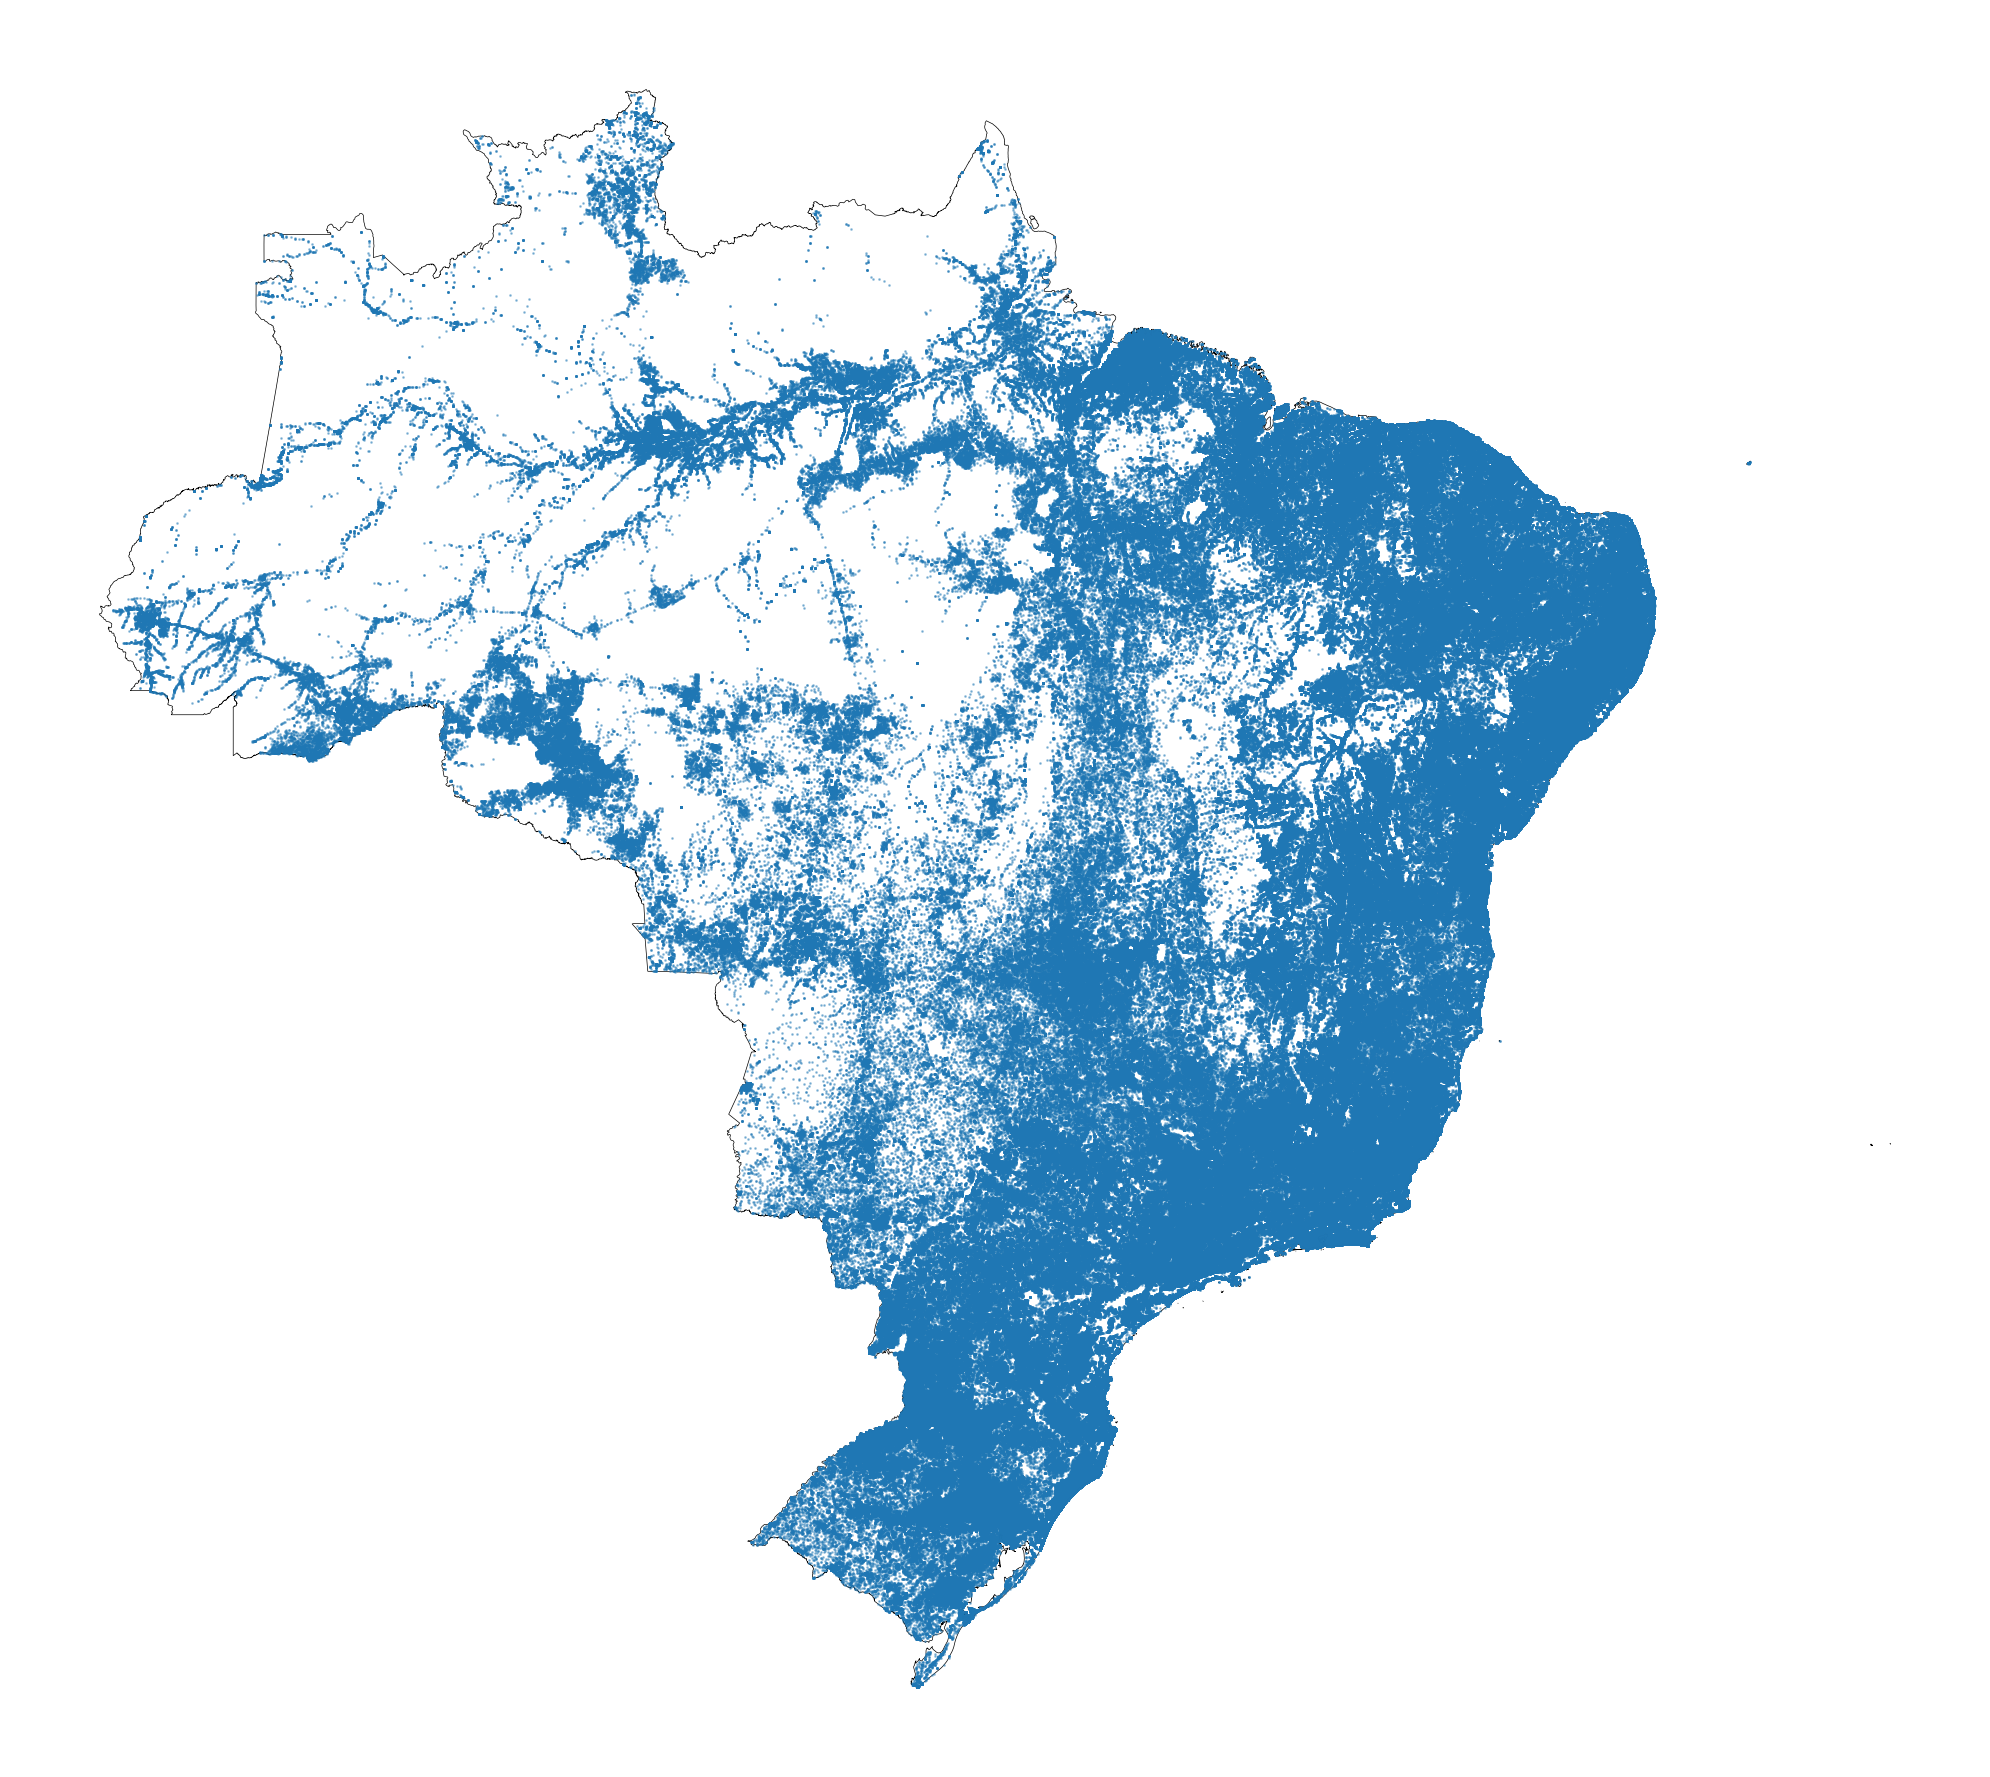

,LONGITUDE,LATITUDE,geometry
0,-38.496721,-12.957379,POINT (-38.49672 -12.95738)
1,-38.430853,-12.901955,POINT (-38.43085 -12.90196)
2,-38.457532,-12.927270,POINT (-38.45753 -12.92727)
3,-38.485262,-12.988272,POINT (-38.48526 -12.98827)
4,-38.498927,-12.967850,POINT (-38.49893 -12.96785)
...,...,...,...
11107843,-53.032036,-16.857647,POINT (-53.03204 -16.85765)
11107844,-53.032259,-16.857721,POINT (-53.03226 -16.85772)
11107845,-53.029737,-16.857325,POINT (-53.02974 -16.85732)
11107846,-53.030199,-16.857480,POINT (-53.0302 -16.85748)


In [45]:
plot_brazil_coordinates(
    df,
    longitude_col="LONGITUDE",
    latitude_col="LATITUDE",
    seed=42,
    figsize=(20, 20),
    sample_fraction=0.1,
    markersize=1,
    alpha=0.4
)

Loaded undefined expressions for column: NOME_LOGRADOURO
Loaded undefined expressions for column: NOM_TIPO_SEGLOGR
Loaded undefined expressions for column: DSC_LOCALIDADE


/home/lucas-vital/projects/brazilian_address_linkage/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/lucas-vital/projects/brazilian_address_linkage/.venv/lib/python3.13/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/home/lucas-vital/projects/brazilian_address_linkage/.venv/lib/python3.13/site-packages/urllib3/connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/a

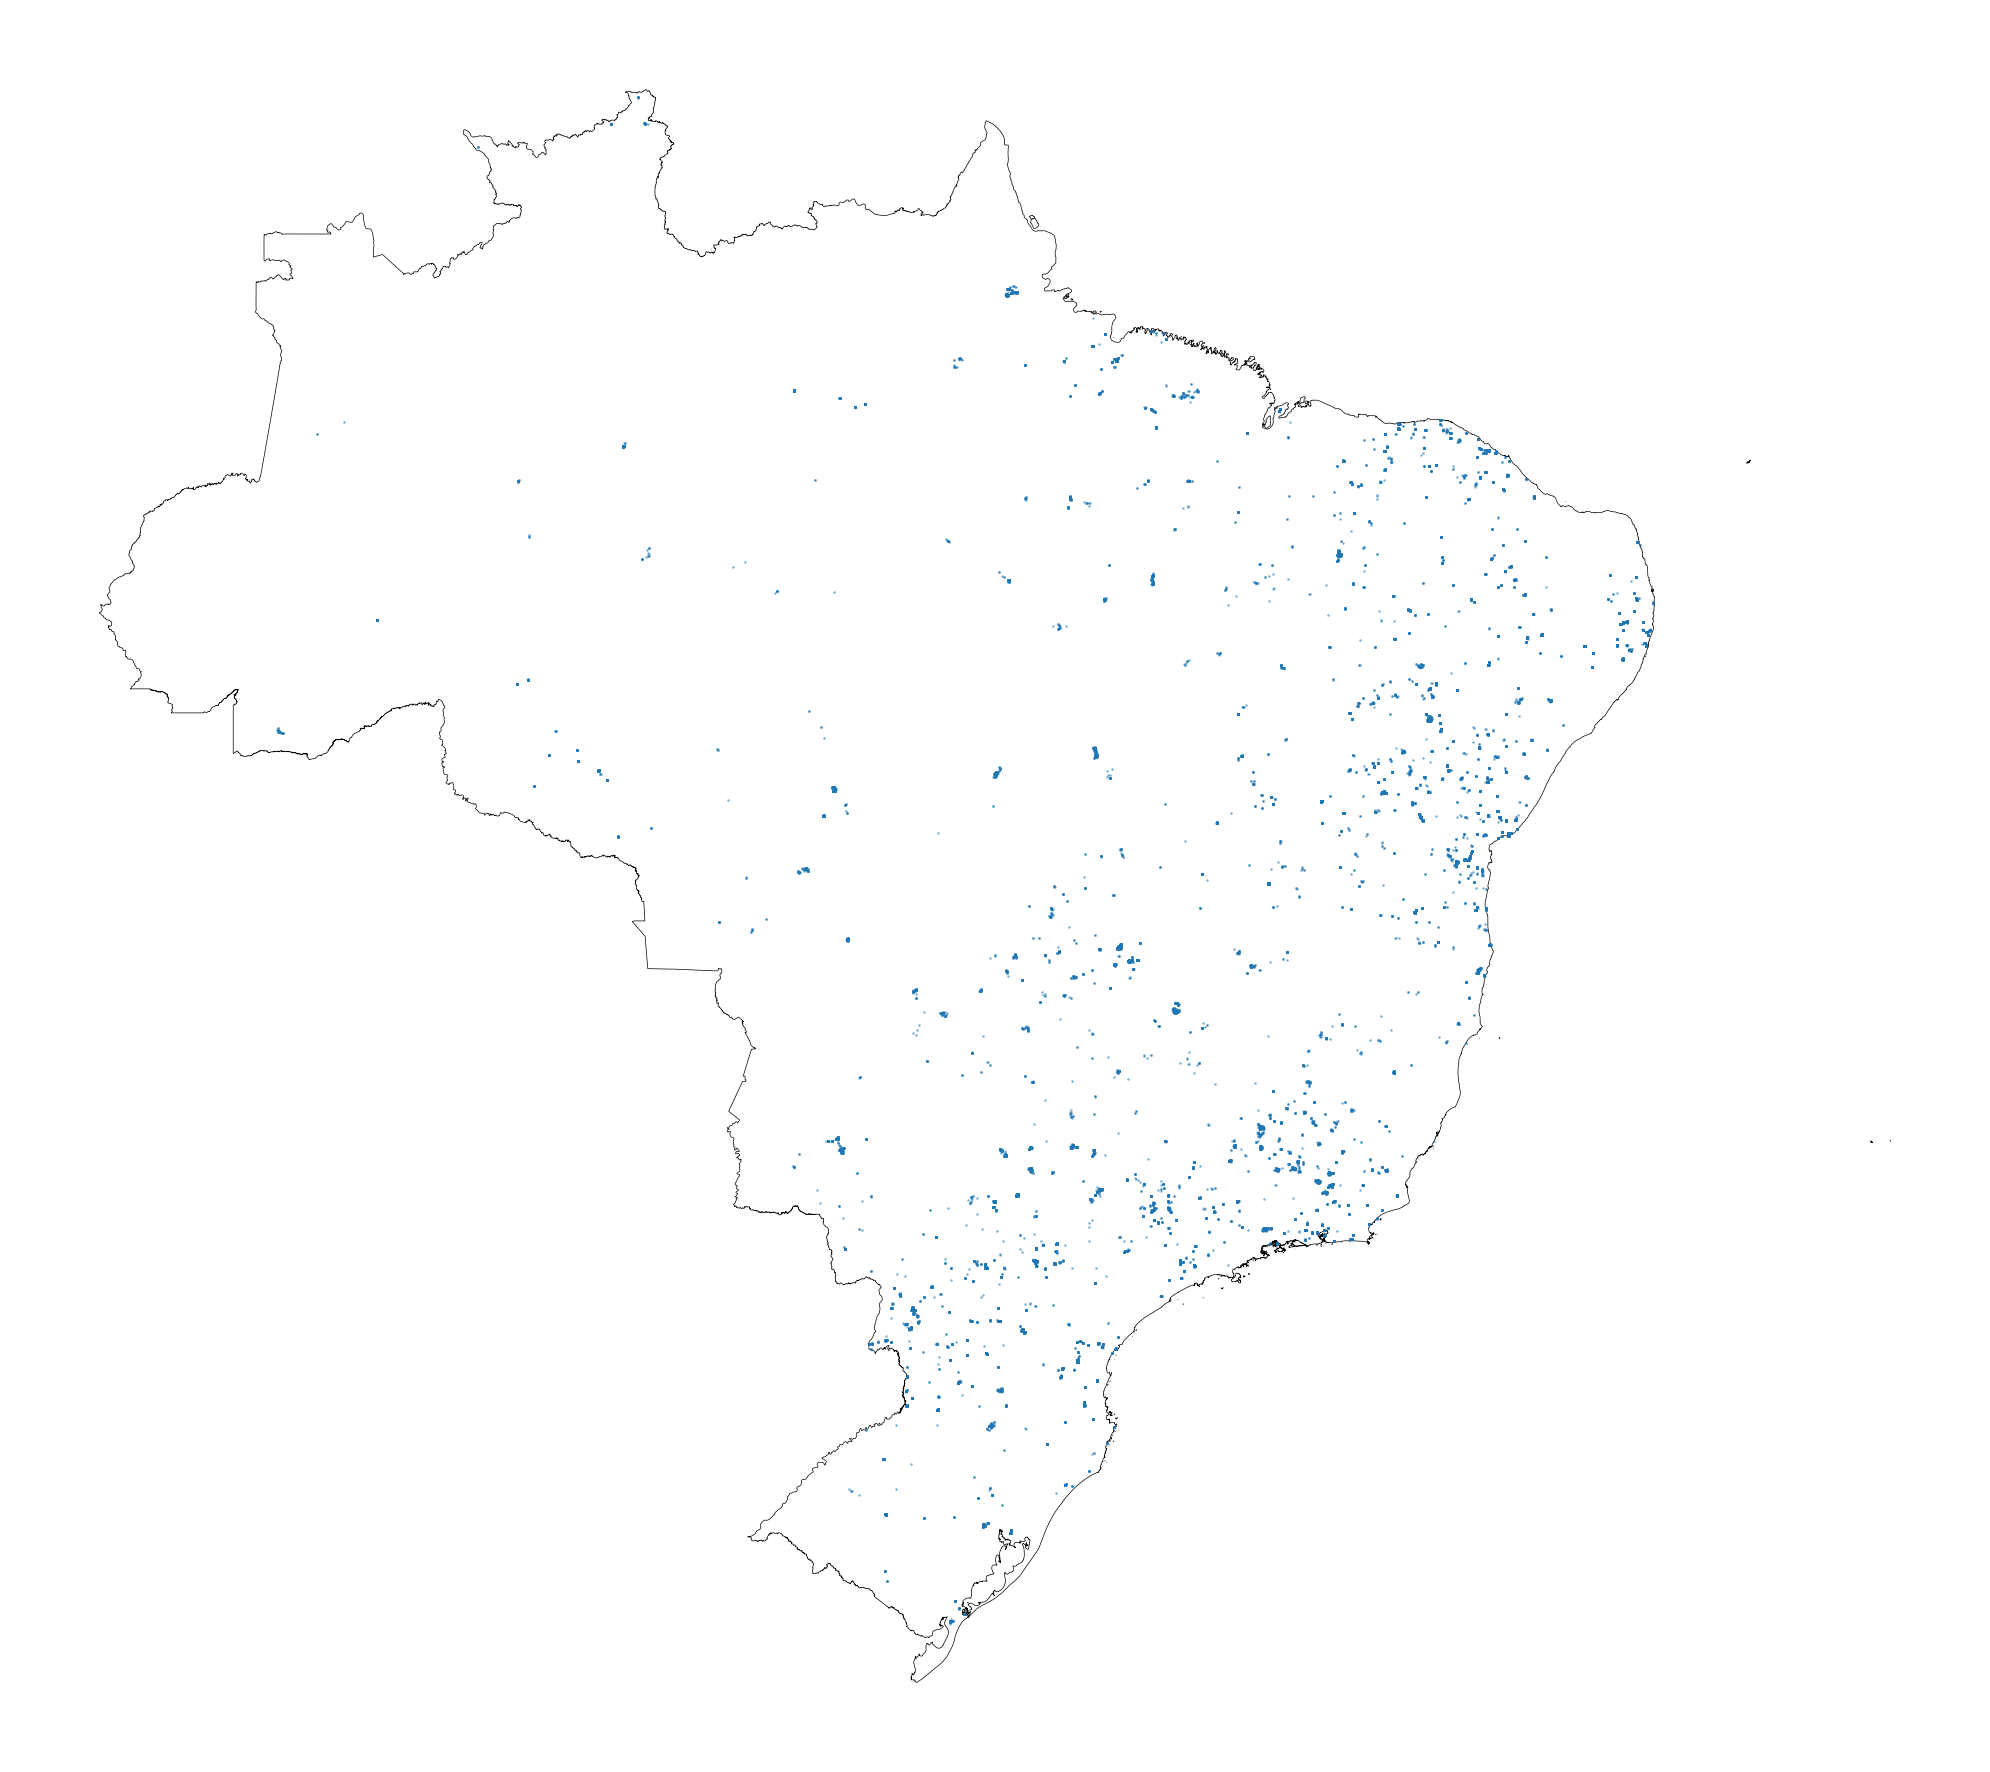

,LONGITUDE,LATITUDE,geometry
0,-38.408629,-12.937092,POINT (-38.40863 -12.93709)
1,-38.478405,-12.942371,POINT (-38.4784 -12.94237)
2,-38.477177,-12.940975,POINT (-38.47718 -12.94098)
3,-38.479024,-12.941092,POINT (-38.47902 -12.94109)
4,-38.484349,-12.938707,POINT (-38.48435 -12.93871)
...,...,...,...
35125,-60.272059,4.445975,POINT (-60.27206 4.44598)
35126,-60.261967,4.450541,POINT (-60.26197 4.45054)
35127,-60.261967,4.450541,POINT (-60.26197 4.45054)
35128,-38.743856,-8.661036,POINT (-38.74386 -8.66104)


In [42]:
plot_brazil_coordinates(
    df.filter(
        is_undefined(F.col("NOM_SEGLOGR"), "NOME_LOGRADOURO")
        | is_undefined(F.col("NOM_TIPO_SEGLOGR"), "NOM_TIPO_SEGLOGR")
        | is_undefined(F.col("DSC_LOCALIDADE"), "DSC_LOCALIDADE")
    ),
    longitude_col="LONGITUDE",
    latitude_col="LATITUDE",
    seed=42,
    figsize=(20, 20),
    markersize=1,
    alpha=0.4
)

#### Análise amostra

In [14]:
df.filter(
    is_undefined(F.col("NOM_SEGLOGR"), "NOME_LOGRADOURO")
    | is_undefined(F.col("NOM_TIPO_SEGLOGR"), "NOM_TIPO_SEGLOGR")
    | is_undefined(F.col("DSC_LOCALIDADE"), "DSC_LOCALIDADE")
).sample(fraction=0.01).toPandas()

Loaded undefined expressions for column: NOME_LOGRADOURO
Loaded undefined expressions for column: NOM_TIPO_SEGLOGR
Loaded undefined expressions for column: DSC_LOCALIDADE


/home/lucas-vital/projects/brazilian_address_linkage/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,COD_UNICO_ENDERECO,COD_UF,COD_MUNICIPIO,COD_DISTRITO,COD_SUBDISTRITO,COD_SETOR,NUM_QUADRA,NUM_FACE,CEP,DSC_LOCALIDADE,...,LATITUDE,LONGITUDE,NV_GEO_COORD,COD_ESPECIE,DSC_ESTABELECIMENTO,COD_INDICADOR_ESTAB_ENDERECO,COD_INDICADOR_CONST_ENDERECO,COD_INDICADOR_FINALIDADE_CONST,COD_TIPO_ESPECI,UF
0,28075161,29,2927408,292740805,29274080522,292740805220552P,1,2,40354555,FAZENDA GRANDE DO RETIRO,...,-12.939596,-38.482947,1,1,NaN,NaN,NaN,NaN,101.0,BA
1,91116400,29,2927408,292740805,29274080522,292740805220361P,1,2,40349435,ALTO DO PERU,...,-12.938319,-38.485504,4,1,NaN,NaN,NaN,NaN,103.0,BA
2,222440458,29,2927408,292740805,29274080522,292740805220094P,2,4,40357290,FAZENDA GRANDE DO RETIRO,...,-12.938014,-38.482112,1,1,NaN,NaN,NaN,NaN,101.0,BA
3,27932045,29,2927408,292740805,29274080522,292740805220135P,2,3,40352360,FAZENDA GRANDE,...,-12.942043,-38.478063,1,1,NaN,NaN,NaN,NaN,101.0,BA
4,27861639,29,2927408,292740805,29274080522,292740805220099P,2,1,40352212,FAZENDA GRANDE,...,-12.940373,-38.478862,1,1,NaN,NaN,NaN,NaN,101.0,BA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,216044555,13,1303502,130350205,13035020500,130350205000074P,3,13,69860000,CIDADE BAIXA,...,-7.717655,-67.002881,1,6,OFICINA MAURICIO,1,NaN,NaN,NaN,AM
329,99876317,13,1303502,130350205,13035020500,130350205000074P,3,14,69860000,CIDADE BAIXA,...,-7.718111,-67.003933,1,1,NaN,NaN,NaN,NaN,101.0,AM
330,36096346,31,3156205,315620505,31562050500,315620505000007P,18,11,36604000,SAO FRANCISCO,...,-21.622951,-43.013316,1,1,NaN,NaN,NaN,NaN,101.0,MG
331,7520790,17,1713957,171395705,17139570500,171395705000006P,0,3,77850000,NAO INFORMADO,...,-7.187910,-48.616733,1,1,NaN,NaN,NaN,NaN,101.0,TO


## Data Cleaning & Linkage Options



### Options for Cleaning Data

Consider the following data cleaning steps:

- **Trim whitespace** — Remove leading and trailing whitespace from string values
  *(e.g., `" john smith "` → `"john smith"`)*
- **Remove special characters** from string values
  *(e.g., `"O'Hara"` → `"Ohara"`)*
- **Standardize date formats** as strings in `yyyy-mm-dd` format
- **Expand abbreviations** to full words
  *(e.g., standardize `"St."` and `"Street"` to `"Street"`)*
- **Remove non-null undefined values**
- **Apply phonetics** to address names


### Fields for Probabilistic Linkage

When performing probabilistic linkage, consider using the following fields:
```yaml
- COD_UNICO_ENDERECO
- COD_UF
- COD_MUNICIPIO
- COD_DISTRITO
- COD_SUBDISTRITO
- COD_SETOR
- NUM_QUADRA
- NUM_FACE
- CEP
- NUM_ENDERECO
- LATITUDE
- LONGITUDE
- NV_GEO_COORD
- DSC_LOCALIDADE
- NOM_TIPO_SEGLOGR
- OM_SEGLOGR
```
